In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/METR-LA.csv")

df.head()

,Unnamed: 0,773869,767541,767542,717447,717446,717445,773062,767620,737529,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
0,2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
1,2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2,2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
3,2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
4,2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


***EDA*** **(Exploratory Data Analysis)**

*configurando la primera columna como timestamp*

In [4]:
df["timestamp"] = pd.to_datetime(df["Unnamed: 0"])

df[["timestamp", "773869"]].head()

C:\Users\leona\AppData\Local\Temp\ipykernel_32640\1198988126.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["timestamp"] = pd.to_datetime(df["Unnamed: 0"])


,timestamp,773869
0,2012-03-01 00:00:00,64.375000
1,2012-03-01 00:05:00,62.666667
2,2012-03-01 00:10:00,64.000000
3,2012-03-01 00:15:00,0.000000
4,2012-03-01 00:20:00,0.000000


*ver de cuanto tiempo se ha recolectado la data (rango temporal)*

In [4]:
print("Inicio:", df["timestamp"].min())
print("Fin:", df["timestamp"].max())
print("Duración:", df["timestamp"].max() - df["timestamp"].min())
duracion_dias = df["timestamp"].max() - df["timestamp"].min()
duracion_meses = duracion_dias/30
print("Duración meses:", duracion_meses)

Inicio: 2012-03-01 00:00:00
Fin: 2012-06-27 23:55:00
Duración: 118 days 23:55:00
Duración meses: 3 days 23:11:50


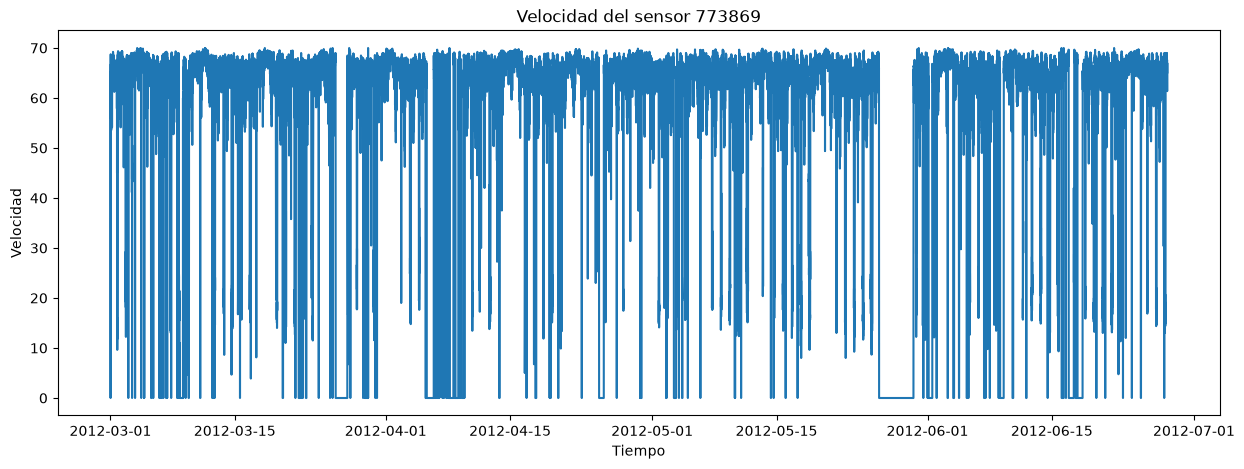

In [5]:
sensor = "773869"

plt.figure(figsize=(15, 5))

plt.plot(
    df["timestamp"],
    df[sensor]
)

plt.title(f"Velocidad del sensor {sensor}")
plt.xlabel("Tiempo")
plt.ylabel("Velocidad")

plt.show()

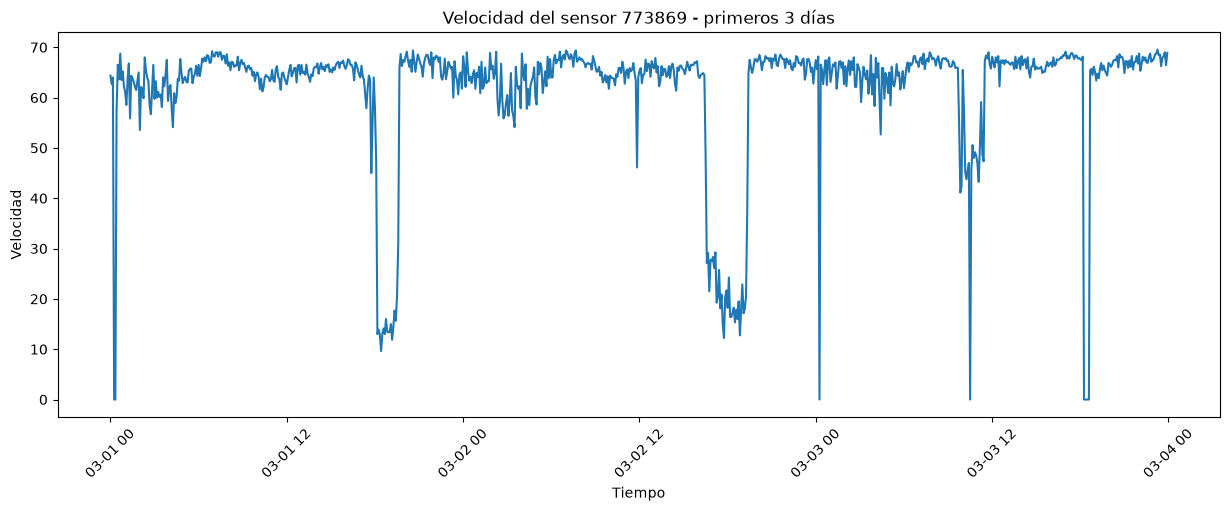

In [6]:
start = df["timestamp"].min()
end = start + pd.Timedelta(days=3)

sample = df[
    (df["timestamp"] >= start) &
    (df["timestamp"] < end)
]

plt.figure(figsize=(15, 5))

plt.plot(
    sample["timestamp"],
    sample[sensor]
)

plt.title(f"Velocidad del sensor {sensor} - primeros 3 días")
plt.xlabel("Tiempo")
plt.ylabel("Velocidad")

plt.xticks(rotation=45)

plt.show()

In [7]:
df["hour"] = df["timestamp"].dt.hour

C:\Users\leona\AppData\Local\Temp\ipykernel_4900\2123767580.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["hour"] = df["timestamp"].dt.hour


In [8]:
hourly_avg = df.groupby("hour")[sensor].mean()

hourly_avg

hour
0     55.342988
1     55.959190
2     54.212028
3     53.103349
4     54.329286
5     56.318081
6     57.412179
7     58.710718
8     57.032187
9     56.812308
10    57.078562
11    57.080267
12    57.350058
13    57.496543
14    57.650786
15    55.248560
16    50.069274
17    36.528920
18    34.085379
19    52.611963
20    60.023532
21    59.697331
22    58.703123
23    58.295994
Name: 773869, dtype: float64

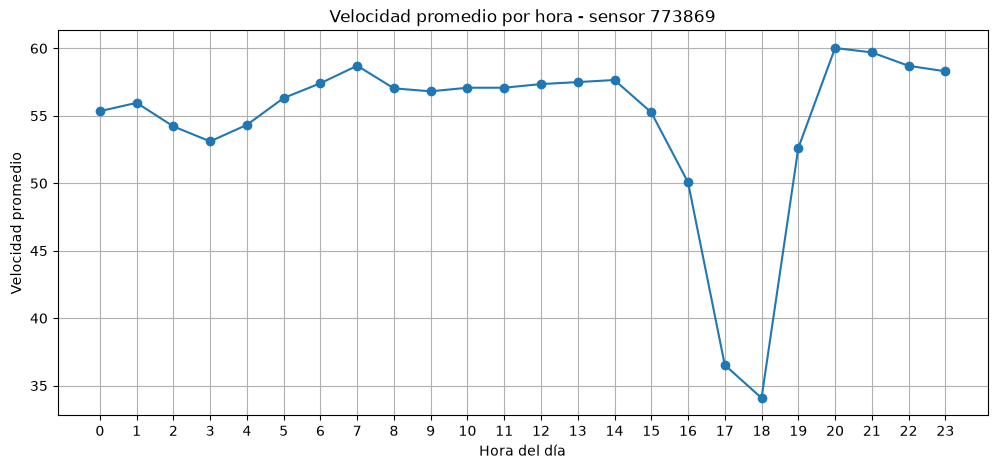

In [9]:
plt.figure(figsize=(12, 5))

plt.plot(hourly_avg.index, hourly_avg.values, marker="o")

plt.title(f"Velocidad promedio por hora - sensor {sensor}")
plt.xlabel("Hora del día")
plt.ylabel("Velocidad promedio")

plt.xticks(range(24))
plt.grid()
plt.show()

In [10]:
df["day_of_week"] = df["timestamp"].dt.day_name()

df.groupby("day_of_week")[sensor].mean()

C:\Users\leona\AppData\Local\Temp\ipykernel_4900\3502184082.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["day_of_week"] = df["timestamp"].dt.day_name()


day_of_week
Friday       52.878070
Monday       52.028523
Saturday     60.246624
Sunday       54.655975
Thursday     53.761195
Tuesday      52.587757
Wednesday    56.261365
Name: 773869, dtype: float64

In [11]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_avg = (
    df.groupby("day_of_week")[sensor]
      .mean()
      .reindex(day_order)
)

daily_avg

day_of_week
Monday       52.028523
Tuesday      52.587757
Wednesday    56.261365
Thursday     53.761195
Friday       52.878070
Saturday     60.246624
Sunday       54.655975
Name: 773869, dtype: float64

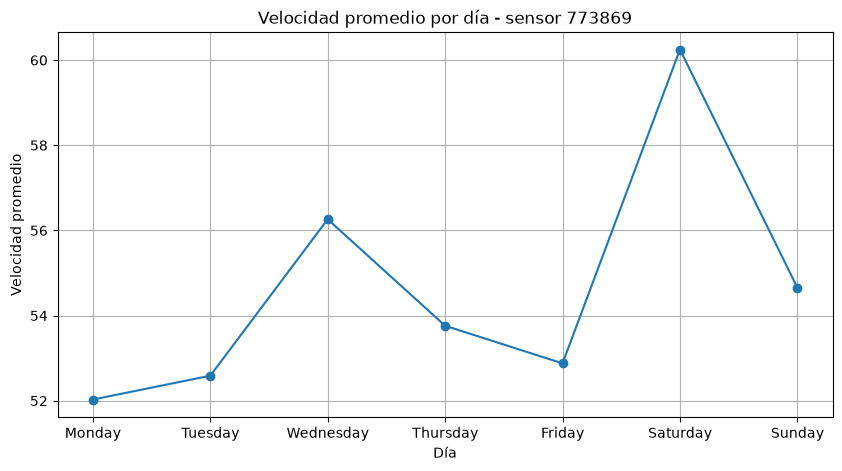

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    daily_avg.index,
    daily_avg.values,
    marker="o"
)

plt.title(f"Velocidad promedio por día - sensor {sensor}")
plt.xlabel("Día")
plt.ylabel("Velocidad promedio")
plt.grid()

plt.show()

In [13]:
df["speed_lag_1"] = df[sensor].shift(1)

df[[sensor, "speed_lag_1"]].corr()

C:\Users\leona\AppData\Local\Temp\ipykernel_4900\3537226107.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["speed_lag_1"] = df[sensor].shift(1)


,773869,speed_lag_1
773869,1.000000,0.952846
speed_lag_1,0.952846,1.000000


In [14]:
df["speed_lag_2"] = df[sensor].shift(2)
df["speed_lag_3"] = df[sensor].shift(3)
df["speed_lag_6"] = df[sensor].shift(6)

df[[sensor, "speed_lag_1", "speed_lag_2",
    "speed_lag_3", "speed_lag_6"]].corr()[sensor]

C:\Users\leona\AppData\Local\Temp\ipykernel_4900\1618533482.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["speed_lag_2"] = df[sensor].shift(2)
C:\Users\leona\AppData\Local\Temp\ipykernel_4900\1618533482.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["speed_lag_3"] = df[sensor].shift(3)
C:\Users\leona\AppData\Local\Temp\ipykernel_4900\1618533482.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining 

773869         1.000000
speed_lag_1    0.952846
speed_lag_2    0.918971
speed_lag_3    0.895400
speed_lag_6    0.833358
Name: 773869, dtype: float64

In [15]:
sensor_columns = [
    col for col in df.columns
    if col.isdigit()
]

sensor_corr = (
    df[sensor_columns]
    .corr()["773869"]
    .drop("773869")
    .sort_values(ascending=False)
)

sensor_corr.head(10)

718204    0.845985
761003    0.756389
717576    0.749795
773953    0.723617
717573    0.701547
717578    0.684136
773904    0.679181
764949    0.677169
765176    0.675183
717463    0.673536
Name: 773869, dtype: float64

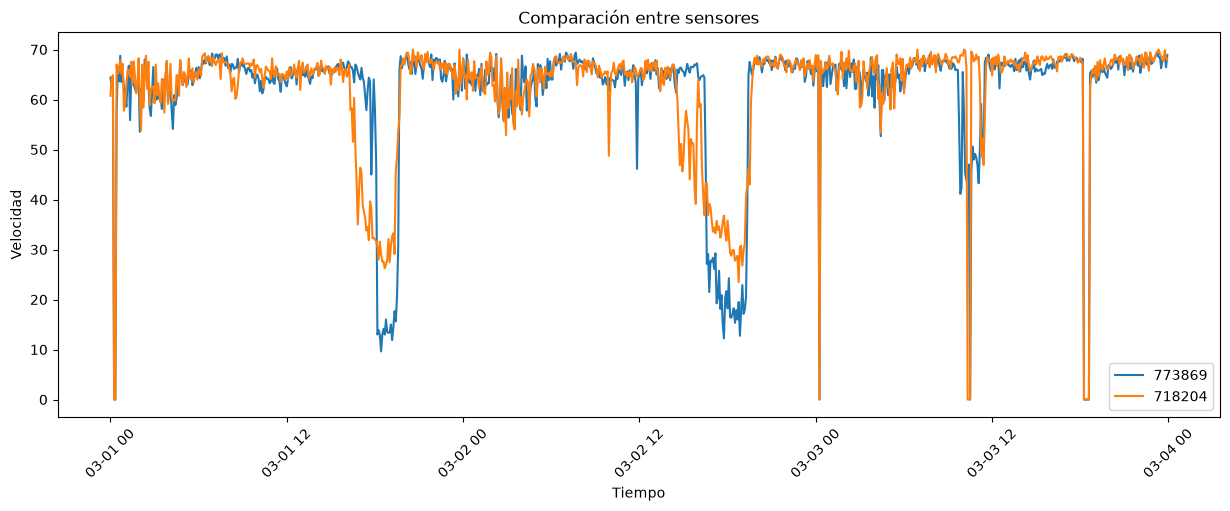

In [16]:
plt.figure(figsize=(15, 5))

plt.plot(
    sample["timestamp"],
    sample["773869"],
    label="773869"
)

plt.plot(
    sample["timestamp"],
    sample["718204"],
    label="718204"
)

plt.title("Comparación entre sensores")
plt.xlabel("Tiempo")
plt.ylabel("Velocidad")
plt.legend()
plt.xticks(rotation=45)

plt.show()

In [17]:
df["sensor_718204_lag_1"] = df["718204"].shift(1)

df[["773869", "sensor_718204_lag_1"]].corr()

C:\Users\leona\AppData\Local\Temp\ipykernel_4900\634768315.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["sensor_718204_lag_1"] = df["718204"].shift(1)


,773869,sensor_718204_lag_1
773869,1.000000,0.824329
sensor_718204_lag_1,0.824329,1.000000


In [18]:
for lag in [1, 2, 3, 6]:
    df[f"718204_lag_{lag}"] = df["718204"].shift(lag)

corrs = {}

for lag in [1, 2, 3, 6]:
    corrs[lag] = df["773869"].corr(df[f"718204_lag_{lag}"])

corrs

C:\Users\leona\AppData\Local\Temp\ipykernel_4900\2756475854.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"718204_lag_{lag}"] = df["718204"].shift(lag)


{1: np.float64(0.8243290674752024),
 2: np.float64(0.8090027975733814),
 3: np.float64(0.7968831529466688),
 6: np.float64(0.7629911520129691)}

In [19]:
import pickle

with open("../data/adj_mx_METR-LA.pkl", "rb") as f:
    adj = pickle.load(f, encoding="latin1")

print(type(adj))

<class 'list'>


In [20]:
if hasattr(adj, "shape"):
    print("Shape:", adj.shape)

In [21]:
print("Tipo:", type(adj))
print("Longitud:", len(adj))

for i, item in enumerate(adj):
    print(f"Elemento {i}:")
    print("  Tipo:", type(item))
    
    if hasattr(item, "shape"):
        print("  Shape:", item.shape)
    elif hasattr(item, "__len__"):
        print("  Longitud:", len(item))

Tipo: <class 'list'>
Longitud: 3
Elemento 0:
  Tipo: <class 'list'>
  Longitud: 207
Elemento 1:
  Tipo: <class 'dict'>
  Longitud: 207
Elemento 2:
  Tipo: <class 'numpy.ndarray'>
  Shape: (207, 207)


In [33]:
adj_matrix = adj[2]

sensor_id = "773869"
sensor_index = adj[1][sensor_id]

neighbors = adj_matrix[sensor_index]

In [ ]:
import numpy as np

neighbor_indices = np.where(neighbors > 0)[0]

print("Número de vecinos:", len(neighbor_indices))
print("Índices:", neighbor_indices)

In [35]:
neighbor_ids = [adj[0][i] for i in neighbor_indices]

print("Sensores vecinos:")
print(neighbor_ids)

Sensores vecinos:
['773869', '773906', '718204', '773927', '773953', '773916', '717572', '718090', '718496', '773904', '761003', '774204']


In [36]:
neighbor_correlations = sensor_corr.loc[
    sensor_corr.index.intersection(neighbor_ids)
]

neighbor_correlations = neighbor_correlations.sort_values(
    ascending=False
)

neighbor_correlations

718204    0.845985
761003    0.756389
773953    0.723617
773904    0.679181
773916    0.671170
717572    0.666537
773927    0.591899
773906    0.577376
774204    0.518453
718496    0.510626
718090    0.433525
Name: 773869, dtype: float64

In [37]:
zero_count = (df["773869"] == 0).sum()
zero_percentage = (df["773869"] == 0).mean() * 100

print("Cantidad de ceros:", zero_count)
print("Porcentaje de ceros:", zero_percentage)

Cantidad de ceros: 3843
Porcentaje de ceros: 11.213235294117647


In [40]:
# ---------------------------------------------------------
# DETECTAR BLOQUES CONSECUTIVOS DE CEROS
# ---------------------------------------------------------

# Creamos una serie booleana:
# True  -> la velocidad del sensor 773869 es 0
# False -> la velocidad es diferente de 0
zero_mask = df["773869"] == 0


# shift(1) desplaza la serie una posición hacia abajo.
#
# Ejemplo:
#
# Original:  False False True True False
# shift():   NaN   False False True True
#
# Esto nos permite comparar cada fila con la anterior.
previous = zero_mask.shift(1)


# ne() significa "not equal" (diferente).
#
# Comparamos el estado actual con el estado anterior.
#
# Si cambia de:
# False -> True  = empieza un bloque de ceros
# True  -> False = termina un bloque de ceros
#
# Si no cambia:
# True -> True   = seguimos dentro del mismo bloque
# False -> False = seguimos fuera del bloque
changes = zero_mask.ne(previous)


# cumsum() hace una suma acumulada.
#
# Como True equivale a 1 y False a 0,
# cada cambio incrementa el número del grupo.
#
# De esta manera cada bloque queda identificado
# con un número diferente.
groups = changes.cumsum()


# Nos quedamos únicamente con las filas donde
# el sensor tiene velocidad 0.
#
# Después agrupamos esas filas usando el identificador
# de grupo que acabamos de crear.
zero_blocks = (
    df[zero_mask]
    .groupby(groups[zero_mask])
    .agg(
        # Primer momento en que aparece el bloque de ceros.
        start=("timestamp", "min"),

        # Último momento en que aparece el bloque.
        end=("timestamp", "max"),

        # Cantidad de mediciones consecutivas con valor 0.
        count=("773869", "size")
    )
)

# Mostramos los primeros bloques encontrados.
zero_blocks.head(20)

,start,end,count
773869,,,
2,2012-03-01 00:15:00,2012-03-01 00:20:00,2
4,2012-03-03 00:15:00,2012-03-03 00:15:00,1
6,2012-03-03 10:30:00,2012-03-03 10:30:00,1
8,2012-03-03 18:15:00,2012-03-03 18:35:00,5
10,2012-03-04 11:05:00,2012-03-04 11:10:00,2
12,2012-03-04 18:35:00,2012-03-04 18:45:00,3
14,2012-03-04 19:00:00,2012-03-04 19:00:00,1
16,2012-03-04 19:10:00,2012-03-04 19:10:00,1
18,2012-03-05 13:30:00,2012-03-05 14:50:00,17


In [41]:
# ---------------------------------------------------------
# CALCULAR DURACIÓN DE LOS BLOQUES
# ---------------------------------------------------------

# Cada fila del dataset representa 5 minutos.
#
# Por ejemplo:
# count = 1 -> 5 minutos
# count = 2 -> 10 minutos
# count = 6 -> 30 minutos
#
# Multiplicamos la cantidad de mediciones por 5.
zero_blocks["duration_minutes"] = zero_blocks["count"] * 5


# Ordenamos los bloques desde el más largo
# hasta el más corto.
#
# sort_values() ordena los valores de una columna.
zero_blocks = zero_blocks.sort_values(
    "duration_minutes",
    ascending=False
)


# Mostramos los 20 bloques de ceros más largos.
zero_blocks.head(20)

,start,end,count,duration_minutes
773869,,,,
226,2012-05-26 12:55:00,2012-05-30 10:00:00,1118,5590
88,2012-03-26 08:25:00,2012-03-27 16:05:00,381,1905
112,2012-04-05 14:35:00,2012-04-06 09:35:00,229,1145
268,2012-06-16 21:30:00,2012-06-17 11:15:00,166,830
272,2012-06-17 21:15:00,2012-06-18 11:00:00,166,830
186,2012-04-25 00:15:00,2012-04-25 13:10:00,156,780
156,2012-04-08 04:10:00,2012-04-08 14:40:00,127,635
232,2012-06-01 02:55:00,2012-06-01 12:55:00,121,605
256,2012-06-09 04:05:00,2012-06-09 13:50:00,118,590


In [ ]:
zero_mask = df["773869"] == 0                         # == compara cada valor con 0

changes = zero_mask.ne(zero_mask.shift())             # shift() desplaza 1 fila; ne() compara si son diferentes

groups = changes.cumsum()                             # cumsum() hace una suma acumulada de los cambios

zero_blocks = (                                       
    df[zero_mask]                                     # Filtra solo las filas donde speed = 0
    .groupby(groups[zero_mask])                       # groupby() agrupa según el número de bloque
    .agg(
        start=("timestamp", "min"),                   # min() obtiene el primer timestamp
        end=("timestamp", "max"),                     # max() obtiene el último timestamp
        count=("773869", "size")                      # size() cuenta las filas del grupo
    )
)

zero_blocks["duration_minutes"] = zero_blocks["count"] * 5  # Cada fila representa 5 minutos

zero_blocks.sort_values(                          # sort_values() ordena los resultados
    "duration_minutes",                           # Columna que queremos ordenar
    ascending=False                               # False = de mayor a menor
).head(20)                                        # head(20) muestra las primeras 20 filas

,start,end,count,duration_minutes
773869,,,,
226,2012-05-26 12:55:00,2012-05-30 10:00:00,1118,5590
88,2012-03-26 08:25:00,2012-03-27 16:05:00,381,1905
112,2012-04-05 14:35:00,2012-04-06 09:35:00,229,1145
268,2012-06-16 21:30:00,2012-06-17 11:15:00,166,830
272,2012-06-17 21:15:00,2012-06-18 11:00:00,166,830
186,2012-04-25 00:15:00,2012-04-25 13:10:00,156,780
156,2012-04-08 04:10:00,2012-04-08 14:40:00,127,635
232,2012-06-01 02:55:00,2012-06-01 12:55:00,121,605
256,2012-06-09 04:05:00,2012-06-09 13:50:00,118,590


In [ ]:
# Reemplazamos temporalmente los 0 por NaN
sensor_clean = df["773869"].replace(0, np.nan)       # replace() sustituye valores; NaN representa un dato faltante

# Contamos los valores faltantes
missing_count = sensor_clean.isna().sum()            # isna() detecta NaN; sum() los cuenta

# Calculamos qué porcentaje representan
missing_percentage = sensor_clean.isna().mean() * 100 # mean() calcula la proporción de NaN

print("Datos faltantes:", missing_count)
print("Porcentaje:", missing_percentage)

Datos faltantes: 3843
Porcentaje: 11.213235294117647


In [10]:
# Obtenemos el bloque de ceros más largo
longest_block = zero_blocks.iloc[0]                  # iloc[0] obtiene la primera fila

print("Inicio:", longest_block["start"])
print("Fin:", longest_block["end"])
print("Duración:", longest_block["duration_minutes"], "minutos")

Inicio: 2012-03-01 00:15:00
Fin: 2012-03-01 00:20:00
Duración: 10 minutos


In [11]:
# Ordenamos los bloques de mayor a menor duración
zero_blocks = zero_blocks.sort_values("duration_minutes", ascending=False)  # sort_values() ordena por una columna

# Mostramos el bloque más largo
print(zero_blocks.iloc[0])  # iloc[0] obtiene la primera fila

start               2012-05-26 12:55:00
end                 2012-05-30 10:00:00
count                              1118
duration_minutes                   5590
Name: 226, dtype: object


### Conclusión sobre los valores cero

El sensor 773869 contiene 3,843 valores iguales a cero,
equivalentes al 11.21% de las observaciones.

Además, los ceros aparecen en bloques prolongados. El bloque
más largo dura 5,590 minutos (aproximadamente 93 horas).

Por esta razón, los valores cero se considerarán como datos
faltantes y deberán tratarse antes de entrenar el modelo.